**Import Libraries**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

**Load Dataset**

In [5]:
df = pd.read_excel("Telco_customer_churn.xlsx")

In [6]:
df

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,2569-WGERO,1,United States,California,Landers,92285,"34.341737, -116.539416",34.341737,-116.539416,Female,...,Two year,Yes,Bank transfer (automatic),21.15,1419.4,No,0,45,5306,NaN
7039,6840-RESVB,1,United States,California,Adelanto,92301,"34.667815, -117.536183",34.667815,-117.536183,Male,...,One year,Yes,Mailed check,84.80,1990.5,No,0,59,2140,NaN
7040,2234-XADUH,1,United States,California,Amboy,92304,"34.559882, -115.637164",34.559882,-115.637164,Female,...,One year,Yes,Credit card (automatic),103.20,7362.9,No,0,71,5560,NaN
7041,4801-JZAZL,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,...,Month-to-month,Yes,Electronic check,29.60,346.45,No,0,59,2793,NaN


**Exploratory Data Analysis**

In [7]:
df.shape

(7043, 33)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [9]:
df["Churn Label"].value_counts()

,count
Churn Label,
No,5174
Yes,1869


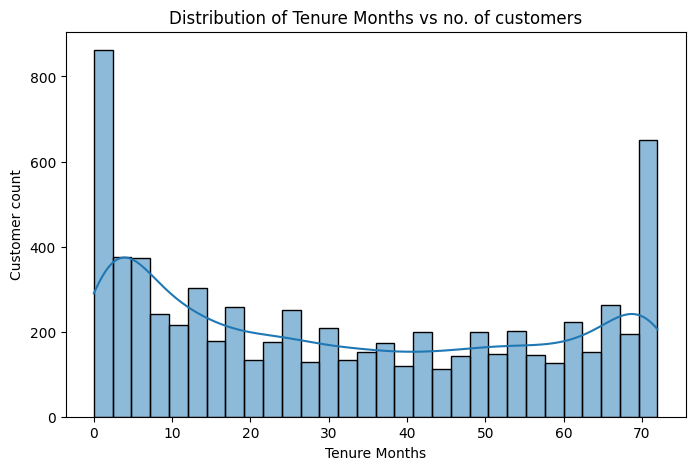

In [10]:
# Distribution of Customer Tenure
plt.figure(figsize=(8,5))
sns.histplot(df['Tenure Months'],bins=30,kde=True)
plt.xlabel('Tenure Months')
plt.ylabel('Customer count')
plt.title('Distribution of Tenure Months vs no. of customers')
plt.show()

In [11]:
df['Tenure Months'].max()

72

In [12]:
df['Tenure Months'].min()

0

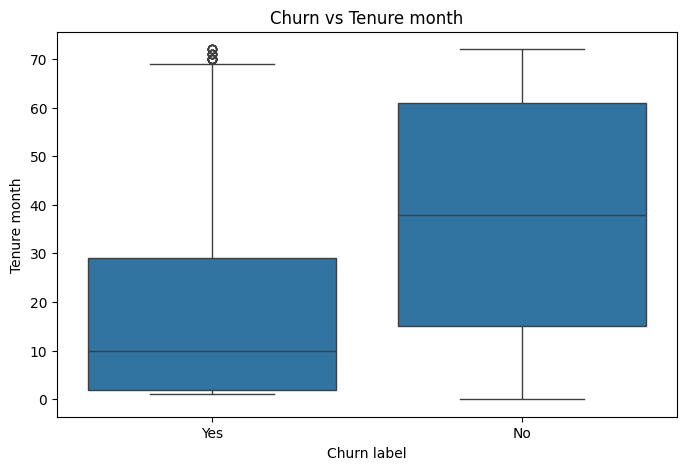

In [13]:
# Analyze relationship between customer tenure and churn
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Tenure Months',data = df)
plt.xlabel('Churn label')
plt.ylabel('Tenure month')
plt.title('Churn vs Tenure month')
plt.show()

In [14]:
# Insights from the Boxplot

# Customers with lower tenure are more likely to churn.
# The median tenure of churned customers is approximately 10 months,
# whereas retained customers have a median tenure of around 38 months.

# Customers with longer tenure tend to be more loyal and are less likely to leave the company.

# These observations suggest that customer tenure is an important factor
# influencing churn behavior and should be considered in churn prediction models.

In [15]:
# To find the categories of a particular column.
df['Churn Label'].unique()

array(['Yes', 'No'], dtype=object)

In [16]:
# Selecting those rows that have 'yes' churn label
df[df['Churn Label'] == 'Yes']

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1864,1699-HPSBG,1,United States,California,Palm Springs,92264,"33.745746, -116.514215",33.745746,-116.514215,Male,...,One year,Yes,Electronic check,59.80,727.8,Yes,1,69,4581,Competitor offered higher download speeds
1865,8775-CEBBJ,1,United States,California,Seeley,92273,"32.790282, -115.689559",32.790282,-115.689559,Female,...,Month-to-month,Yes,Bank transfer (automatic),44.20,403.35,Yes,1,87,2029,Competitor offered higher download speeds
1866,6894-LFHLY,1,United States,California,Vidal,92280,"34.264124, -114.717964",34.264124,-114.717964,Male,...,Month-to-month,Yes,Electronic check,75.75,75.75,Yes,1,97,5571,Competitor offered higher download speeds
1867,0639-TSIQW,1,United States,California,White Water,92282,"33.972293, -116.654195",33.972293,-116.654195,Female,...,Month-to-month,Yes,Credit card (automatic),102.95,6886.25,Yes,1,70,5620,Competitor offered more data


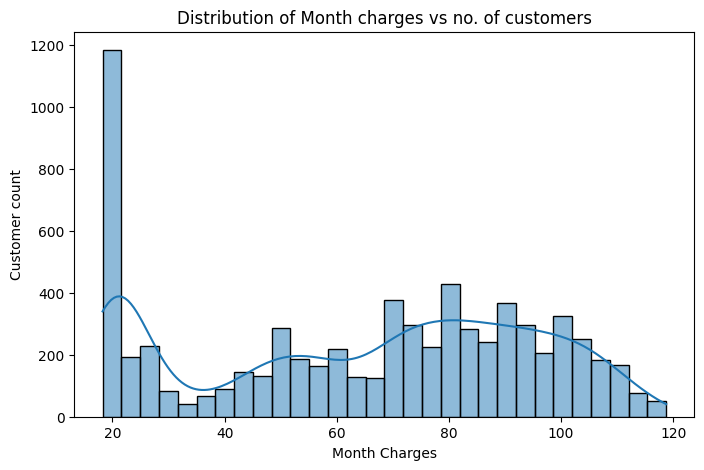

In [17]:
# Distribution of Monthly Charges
plt.figure(figsize=(8,5))
sns.histplot(df['Monthly Charges'],bins=30,kde=True)
plt.xlabel('Month Charges')
plt.ylabel('Customer count')
plt.title('Distribution of Month charges vs no. of customers')
plt.show()

In [18]:
df['Monthly Charges'].max()

118.75

In [19]:
df['Monthly Charges'].min()

18.25

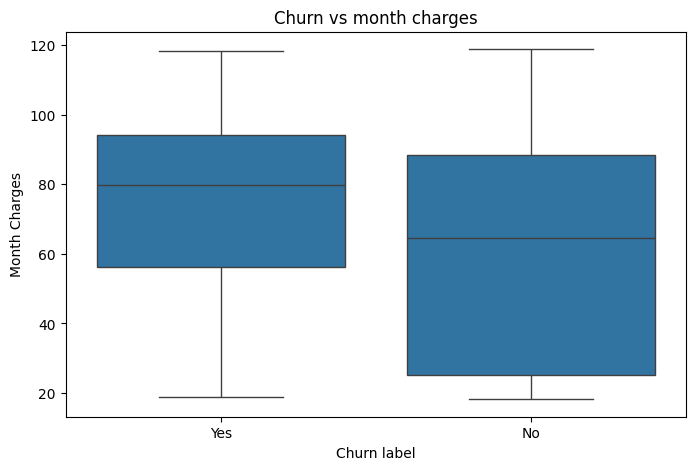

In [20]:
plt.figure(figsize=(8,5))
sns.boxplot(x='Churn Label', y='Monthly Charges',data = df)
plt.xlabel('Churn label')
plt.ylabel('Month Charges')
plt.title('Churn vs month charges')
plt.show()

In [21]:
# Interpretation

# Customers with higher monthly charges tend to exhibit a higher churn rate.
# The median monthly charge of churned customers is approximately 80,whereas retained customers have a median monthly charge of around 65.
# This suggests that customers paying higher monthly charges may be more likely to discontinue the service.
# Monthly Charges appears to be an important feature for churn prediction.

In [22]:
# find the quartile of the monthly charges of those customers that are leaving thecompany.
df[df['Churn Label'] == 'Yes']['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,56.15
0.50,79.65
0.75,94.20


In [23]:
df['Monthly Charges'].describe()

,Monthly Charges
count,7043.000000
mean,64.761692
std,30.090047
min,18.250000
25%,35.500000
50%,70.350000
75%,89.850000
max,118.750000


In [24]:
df['Monthly Charges'].quantile([0.25,0.5,0.75])

,Monthly Charges
0.25,35.50
0.50,70.35
0.75,89.85


In [25]:
df['Contract'].unique()

array(['Month-to-month', 'Two year', 'One year'], dtype=object)

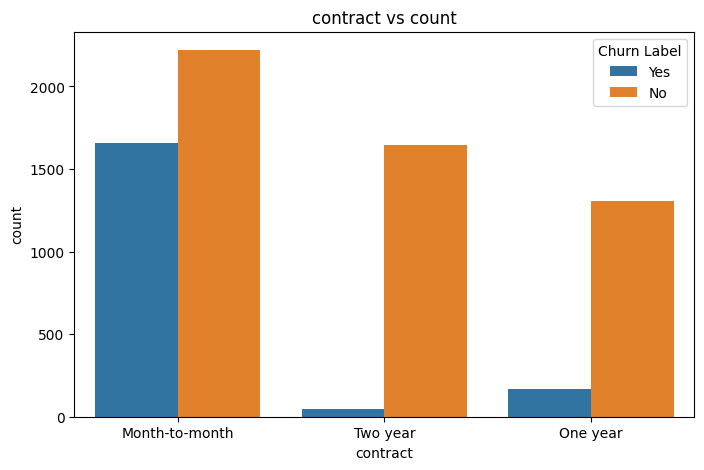

In [26]:
# Analyze churn across different contract types
plt.figure(figsize=(8,5))
sns.countplot(x='Contract', hue='Churn Label', data=df)
plt.xlabel('contract')
plt.ylabel('count')
plt.title('contract vs count')
plt.show()

In [27]:
# Interpretation

# Customers with month-to-month contracts exhibit the highest churn rate.
# Customers with one-year and two-year contracts are more likely to remain with the company.
# Long-term contracts increase customer commitment and reduce the likelihood of churn.
# Customers on month-to-month plans have greater flexibility to switch providers,making them more likely to leave the service.
# Contract type appears to be a significant factor influencing customer churn.

In [28]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [30]:
df['Internet Service'].unique()

array(['DSL', 'Fiber optic', 'No'], dtype=object)

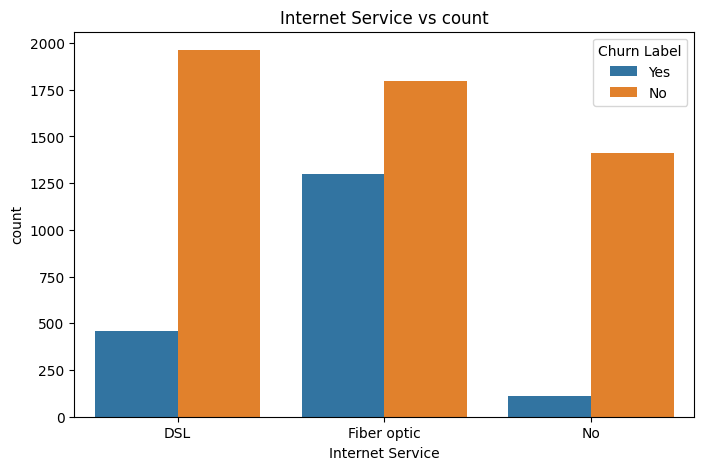

In [31]:
# Internet Service Analysis
plt.figure(figsize=(8,5))
sns.countplot(x='Internet Service', hue='Churn Label', data=df)
plt.xlabel('Internet Service')
plt.ylabel('count')
plt.title('Internet Service vs count')
plt.show()

In [32]:
# Interpretation

# Customers using Fiber Optic services exhibit relatively higher churn rates.
# DSL customers generally show better retention compared to Fiber Optic users.

In [33]:
df['Payment Method'].unique()

array(['Mailed check', 'Electronic check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

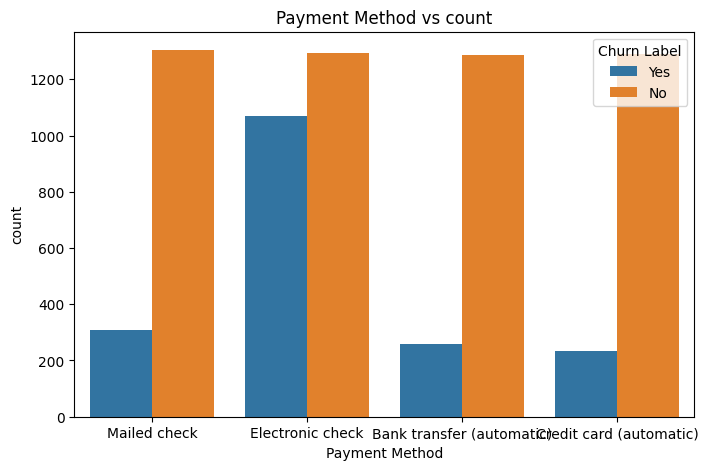

In [34]:
# Payment Method Analysis
plt.figure(figsize=(8,5))
sns.countplot(x='Payment Method', hue='Churn Label', data=df)
plt.xlabel('Payment Method')
plt.ylabel('count')
plt.title('Payment Method vs count')
plt.show()

In [35]:
# Interpretation

# Customers using Electronic Check show the highest churn rate.
# Customers using automatic payment methods tend to have better retention.

In [36]:
df['Tech Support'].unique()

array(['No', 'Yes', 'No internet service'], dtype=object)

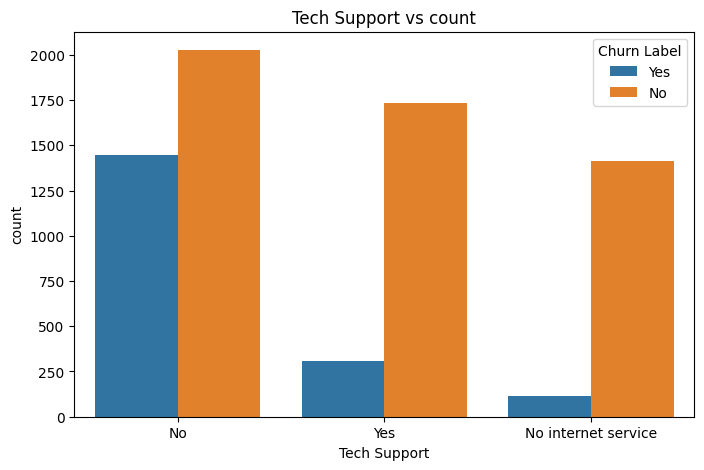

In [37]:
# Analyze the impact of technical support on customer churn
plt.figure(figsize=(8,5))
sns.countplot(x='Tech Support', hue='Churn Label', data=df)
plt.xlabel('Tech Support')
plt.ylabel('count')
plt.title('Tech Support vs count')
plt.show()

In [38]:
# Interpretation

# Customers without technical support show a higher churn rate compared to those who receive technical support.
# Customers who have access to technical support are more likely to remain with the company.
# Technical support helps resolve service-related issues, leading to improved customer satisfaction and retention.
# Lack of technical support may result in unresolved problems, increasing the likelihood of customers leaving the service.
# Therefore, technical support appears to play an important role in reducing customer churn.

In [39]:
# Calculate the average tenure for churned and retained customers.

avg_tenure = df.groupby('Churn Label')['Tenure Months'].mean()
print(avg_tenure)

Churn Label
No     37.569965
Yes    17.979133
Name: Tenure Months, dtype: float64


In [40]:
# Interpretation

# Customers who churned stayed with the company for approximately 17 months on average.
# Customers who remained with the company had an average tenure of approximately 37 months.

# Higher average tenure indicates stronger customer loyalty and lower churn risk.
# This observation further suggests that customer tenure is an important factor influencing churn behavior.

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [42]:
# Correlation Analysis
numerical_cols=['Tenure Months','Monthly Charges','Churn Value','Churn Score','CLTV']
correlation_matrix = df[numerical_cols].corr()

In [43]:
correlation_matrix

,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
Tenure Months,1.000000,0.247900,-0.352229,-0.224987,0.396406
Monthly Charges,0.247900,1.000000,0.193356,0.133754,0.098693
Churn Value,-0.352229,0.193356,1.000000,0.664897,-0.127463
Churn Score,-0.224987,0.133754,0.664897,1.000000,-0.079782
CLTV,0.396406,0.098693,-0.127463,-0.079782,1.000000


In [44]:
# Interpretation

# Higher tenure is associated with lower churn.
# Churn is negatively associated with Customer Lifetime Value (CLTV).

In [45]:
# Bivariate Analysis
contract_churn = pd.crosstab(df['Contract'],df['Churn Label'])
contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,2220,1655
One year,1307,166
Two year,1647,48


In [46]:
contract_churn_percentage = pd.crosstab(df['Contract'],df['Churn Label'],normalize='index')
contract_churn_percentage

Churn Label,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


**Data Cleaning**

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [48]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.5
3,3046.05
4,5036.3
...,...
7038,1419.4
7039,1990.5
7040,7362.9
7041,346.45


In [49]:
df['Total Charges']= pd.to_numeric(df['Total Charges'],errors='coerce')

In [50]:
df['Total Charges']

,Total Charges
0,108.15
1,151.65
2,820.50
3,3046.05
4,5036.30
...,...
7038,1419.40
7039,1990.50
7040,7362.90
7041,346.45


In [51]:
df['Total Charges'].dtype

dtype('float64')

In [52]:
df['Total Charges'].isnull().sum()

np.int64(11)

In [53]:
df[df['Total Charges'].isnull()]['Tenure Months']

,Tenure Months
2234,0
2438,0
2568,0
2667,0
2856,0
4331,0
4687,0
5104,0
5719,0
6772,0


In [54]:
df[df['Total Charges'].isnull()]['Tenure Months'].shape

(11,)

In [55]:
# These 11 records are logically valid because the customers are new and have zero tenure.

In [56]:
df['Total Charges']= df['Total Charges'].fillna(0)

In [57]:
df['Total Charges'].isnull().sum()

np.int64(0)

In [58]:
# Drop Unnecessary columns

# Columns such as Churn Label, Churn Score and Churn Reason contain target-related information.
# Using these variables would introduce data leakage.
# CLTV (Customer Lifetime Value) may also indirectly leak information because a high CLTV can hint at
# future revenue and retention behavior, which is related to the target outcome.

In [59]:
drop_columns = [
    'CustomerID','Count','Country','State','Zip Code','Lat Long','Latitude','Longitude','Churn Label','Churn Score','CLTV','Churn Reason'
]
df = df.drop(columns=drop_columns)

In [60]:
df.shape

(7043, 21)

In [61]:
df['City'].unique
df['City'].value_counts()

,count
City,
Los Angeles,305
San Diego,150
San Jose,112
Sacramento,108
San Francisco,104
...,...
Chester,4
Big Bar,4
Washington,4


In [62]:
# Encode categorical variables using one-hot encoding
df_encoded= pd.get_dummies(df,drop_first=True)

In [63]:
df_encoded.head()

,Tenure Months,Monthly Charges,Total Charges,Churn Value,City_Acton,City_Adelanto,City_Adin,City_Agoura Hills,City_Aguanga,City_Ahwahnee,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,False,False,False,False,False,False,...,False,True,False,True,False,False,True,False,False,False


In [64]:
df_encoded.shape

(7043, 1159)

In [65]:
df=df.drop(columns=['City'])

In [66]:
df_encoded= pd.get_dummies(df,drop_first=True)

In [67]:
df_encoded.shape

(7043, 31)

In [68]:
df_encoded

,Tenure Months,Monthly Charges,Total Charges,Churn Value,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
0,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
1,2,70.70,151.65,1,False,False,False,True,True,False,...,False,False,False,False,False,False,True,False,True,False
2,8,99.65,820.50,1,False,False,False,True,True,False,...,False,True,False,True,False,False,True,False,True,False
3,28,104.80,3046.05,1,False,False,True,True,True,False,...,False,True,False,True,False,False,True,False,True,False
4,49,103.70,5036.30,1,True,False,False,True,True,False,...,False,True,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,72,21.15,1419.40,0,False,False,False,False,True,False,...,True,False,True,False,False,True,True,False,False,False
7039,24,84.80,1990.50,0,True,False,True,True,True,False,...,False,True,False,True,True,False,True,False,False,True
7040,72,103.20,7362.90,0,False,False,True,True,True,False,...,False,True,False,True,True,False,True,True,False,False
7041,11,29.60,346.45,0,False,False,True,True,False,True,...,False,False,False,False,False,False,True,False,True,False


In [73]:
X=df_encoded.drop(columns=['Churn Value'],axis=1)
y=df_encoded['Churn Value']

In [74]:
X.shape
y.shape

(7043,)

In [75]:
print(X)

      Tenure Months  Monthly Charges  Total Charges  Gender_Male  \
0                 2            53.85         108.15         True   
1                 2            70.70         151.65        False   
2                 8            99.65         820.50        False   
3                28           104.80        3046.05        False   
4                49           103.70        5036.30         True   
...             ...              ...            ...          ...   
7038             72            21.15        1419.40        False   
7039             24            84.80        1990.50         True   
7040             72           103.20        7362.90        False   
7041             11            29.60         346.45        False   
7042             66           105.65        6844.50         True   

      Senior Citizen_Yes  Partner_Yes  Dependents_Yes  Phone Service_Yes  \
0                  False        False           False               True   
1                  False       

In [76]:
print(y)

0       1
1       1
2       1
3       1
4       1
       ..
7038    0
7039    0
7040    0
7041    0
7042    0
Name: Churn Value, Length: 7043, dtype: int64


**Machine Learning implementation**

In [77]:
from sklearn.model_selection import train_test_split

In [78]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [79]:
X_train.shape

(5634, 30)

In [80]:
X_test.shape

(1409, 30)

In [81]:
X_train

,Tenure Months,Monthly Charges,Total Charges,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,Multiple Lines_Yes,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
2142,71,98.65,6962.85,True,False,True,False,True,False,True,...,False,True,False,True,True,False,True,True,False,False
1623,16,93.20,1573.70,False,False,False,False,True,False,False,...,False,False,False,True,False,False,True,True,False,False
6074,32,104.05,3416.85,False,False,False,False,True,False,True,...,False,True,False,True,True,False,True,True,False,False
1362,24,40.65,933.30,False,True,True,False,False,True,False,...,False,False,False,True,False,False,True,True,False,False
6754,20,20.05,406.05,False,False,True,True,True,False,False,...,True,False,True,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3772,42,100.40,4303.65,False,False,True,True,True,False,False,...,False,True,False,True,False,True,True,False,True,False
5191,39,20.70,762.45,False,False,False,False,True,False,False,...,True,False,True,False,False,True,False,True,False,False
5226,19,20.20,387.40,True,False,True,True,True,False,False,...,True,False,True,False,False,True,False,False,False,True
5390,35,19.90,666.00,True,False,True,True,True,False,False,...,True,False,True,False,True,False,False,False,True,False


In [82]:
X_test

,Tenure Months,Monthly Charges,Total Charges,Gender_Male,Senior Citizen_Yes,Partner_Yes,Dependents_Yes,Phone Service_Yes,Multiple Lines_No phone service,Multiple Lines_Yes,...,Streaming TV_No internet service,Streaming TV_Yes,Streaming Movies_No internet service,Streaming Movies_Yes,Contract_One year,Contract_Two year,Paperless Billing_Yes,Payment Method_Credit card (automatic),Payment Method_Electronic check,Payment Method_Mailed check
185,15,85.90,1269.55,False,False,False,False,True,False,False,...,False,False,False,True,False,False,True,False,False,False
2715,18,56.80,1074.65,True,False,True,False,True,False,True,...,False,False,False,False,False,False,False,True,False,False
3825,2,20.00,40.90,False,False,False,False,True,False,False,...,True,False,True,False,False,False,True,False,False,True
1807,6,84.20,519.15,True,True,True,False,True,False,False,...,False,False,False,True,False,False,True,False,True,False
132,40,104.80,4131.95,True,False,False,False,True,False,True,...,False,True,False,True,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6366,66,104.90,6891.45,False,True,True,True,True,False,True,...,False,True,False,True,True,False,True,False,True,False
315,19,86.00,1532.45,True,False,False,False,True,False,True,...,False,False,False,True,False,False,True,False,False,False
2439,2,90.35,190.50,False,False,True,False,True,False,False,...,False,True,False,False,False,False,False,False,True,False
5002,68,110.20,7467.50,True,False,True,True,True,False,True,...,False,True,False,True,False,True,True,False,True,False


In [83]:
y_train.shape

(5634,)

In [84]:
y_test.shape

(1409,)

In [85]:
from sklearn.ensemble import RandomForestClassifier

In [86]:
rf_model = RandomForestClassifier(n_estimators=100,random_state=42)

In [87]:
rf_model.fit(X_train,y_train)

RandomForestClassifier(random_state=42)

In [88]:
y_pred = rf_model.predict(X_test)

In [89]:
y_pred

array([0, 0, 0, ..., 1, 0, 1])

In [90]:
y_test

,Churn Value
185,1
2715,0
3825,0
1807,1
132,1
...,...
6366,0
315,1
2439,0
5002,0


In [91]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test,y_pred)

In [92]:
accuracy

0.7856635911994322

In [93]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[902, 107],
       [195, 205]])

In [94]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.89      0.86      1009
           1       0.66      0.51      0.58       400

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.72      1409
weighted avg       0.78      0.79      0.78      1409



In [95]:
# In churn prediction, recall is more important than precision.

**Approach 1 - Handle class imbalance**

In [96]:
# Handle class imbalance using class weights

In [97]:
rf_balanced = RandomForestClassifier(n_estimators=100,class_weight='balanced',random_state=42)

In [98]:
rf_balanced.fit(X_train,y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [99]:
y_pred_balanced = rf_balanced.predict(X_test)

In [100]:
accuracy_balanced = accuracy_score(y_test,y_pred_balanced)
print(accuracy_balanced)

0.7920511000709723


In [101]:
cm_balanced = confusion_matrix(y_test,y_pred_balanced)
print(cm_balanced)

[[907 102]
 [191 209]]


In [102]:
print(classification_report(y_test,y_pred_balanced))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1009
           1       0.67      0.52      0.59       400

    accuracy                           0.79      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.78      0.79      0.78      1409



**Approach-2 Hyperparameter tuning**

In [103]:
rf_tuned=RandomForestClassifier(n_estimators=300,max_depth= 10,random_state=42,class_weight='balanced')
rf_tuned.fit(X_train,y_train)

y_pred_tuned = rf_tuned.predict(X_test)

accuracy_tuned = accuracy_score(y_test, y_pred_tuned)
print(accuracy_balanced)

cm_tuned = confusion_matrix(y_test, y_pred_tuned)
print(cm_tuned)


print (classification_report(y_test, y_pred_tuned))

0.7920511000709723
[[804 205]
 [101 299]]
              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.59      0.75      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



**Approach-3 Feature Importance Analysis**

In [104]:
import pandas as pd
features_importances_ = pd.DataFrame({
    'Features':X.columns,
    'Importance':rf_tuned.feature_importances_,
    })
features_importances= features_importances_.sort_values(by='Importance',ascending=False)
print(features_importances)

                                  Features  Importance
0                            Tenure Months    0.179069
2                            Total Charges    0.136460
25                       Contract_Two year    0.102861
1                          Monthly Charges    0.093681
6                           Dependents_Yes    0.068517
10            Internet Service_Fiber optic    0.060228
28         Payment Method_Electronic check    0.046732
24                       Contract_One year    0.036682
13                     Online Security_Yes    0.029356
19                        Tech Support_Yes    0.021106
26                   Paperless Billing_Yes    0.018064
5                              Partner_Yes    0.015846
12     Online Security_No internet service    0.014973
18        Tech Support_No internet service    0.014799
22    Streaming Movies_No internet service    0.014360
16   Device Protection_No internet service    0.012985
11                     Internet Service_No    0.012673
3         

In [105]:
print(features_importances.tail(15))

                                  Features  Importance
16   Device Protection_No internet service    0.012985
11                     Internet Service_No    0.012673
3                              Gender_Male    0.012586
15                       Online Backup_Yes    0.012213
9                       Multiple Lines_Yes    0.011690
14       Online Backup_No internet service    0.010298
4                       Senior Citizen_Yes    0.010257
20        Streaming TV_No internet service    0.010186
23                    Streaming Movies_Yes    0.010161
27  Payment Method_Credit card (automatic)    0.009430
21                        Streaming TV_Yes    0.009289
17                   Device Protection_Yes    0.009101
29             Payment Method_Mailed check    0.008800
7                        Phone Service_Yes    0.003872
8          Multiple Lines_No phone service    0.003725


In [107]:
X_selected = X.drop(['Phone Service_Yes','Multiple Lines_No phone service'],axis = 1)

In [108]:
X_train_sel,X_test_sel,y_train_sel,y_test_sel = train_test_split(X_selected,y,test_size=0.20,random_state=42)

In [109]:
rf_selected = RandomForestClassifier(n_estimators=300,max_depth= 10,random_state=42,class_weight='balanced')
rf_selected.fit(X_train_sel,y_train_sel)
y_pred_selected = rf_selected.predict(X_test_sel)

print (classification_report(y_test_sel, y_pred_selected))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.60      0.74      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



**Approach- Combination of trees and depth**

In [110]:
from sklearn.metrics import accuracy_score,recall_score,precision_score ,f1_score

In [111]:
rf_selected=RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')
rf_selected.fit(X_train_sel,y_train_sel)
y_pred_selected=rf_selected.predict(X_test_sel)

print (classification_report(y_test_sel, y_pred_selected))

              precision    recall  f1-score   support

           0       0.89      0.80      0.84      1009
           1       0.60      0.74      0.66       400

    accuracy                           0.78      1409
   macro avg       0.74      0.77      0.75      1409
weighted avg       0.80      0.78      0.79      1409



In [112]:
n_estimators_list=[100,200,300,400,500]
max_depth_list = [5,10,15,20]
results = []
for n_trees in n_estimators_list:
  for depth in max_depth_list:
    rf = RandomForestClassifier(n_estimators=n_trees,
                                    max_depth=depth,
                                    class_weight='balanced'
                                    )

    rf.fit(X_train,y_train)
    y_pred = rf.predict(X_test)
    accuracy = accuracy_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    results.append({'Trees':n_trees,'Depth':depth,'Accuracy':accuracy,'Recall':recall,'Precision':precision,'F1_score':f1_score})
result_df = pd.DataFrame(results)
result_df = result_df.sort_values(by=['Recall','Accuracy'],ascending=False)
print(result_df.head(20))

    Trees  Depth  Accuracy  Recall  Precision  \
8     300      5  0.742370  0.8100   0.530278   
12    400      5  0.741661  0.8100   0.529412   
16    500      5  0.739532  0.8075   0.526917   
4     200      5  0.745209  0.8050   0.533997   
0     100      5  0.738112  0.8000   0.525452   
9     300     10  0.784244  0.7550   0.594488   
1     100     10  0.777857  0.7525   0.584466   
13    400     10  0.783534  0.7475   0.594433   
17    500     10  0.784954  0.7450   0.597194   
5     200     10  0.781405  0.7450   0.591270   
6     200     15  0.801278  0.6325   0.655440   
18    500     15  0.799858  0.6325   0.652062   
2     100     15  0.801278  0.6300   0.656250   
14    400     15  0.802697  0.6275   0.660526   
10    300     15  0.799858  0.6200   0.656085   
7     200     20  0.797729  0.5425   0.680251   
15    400     20  0.792051  0.5350   0.666667   
3     100     20  0.790632  0.5250   0.666667   
19    500     20  0.791341  0.5225   0.669872   
11    300     20  0.

In [113]:
# Cross Validation
from sklearn.model_selection import cross_val_score
final_rf = RandomForestClassifier(n_estimators=300,max_depth=10,random_state=42,class_weight='balanced')
cv_accuracy = cross_val_score(final_rf,X,y,cv=5,scoring='accuracy')
print(cv_accuracy)
print(cv_accuracy.mean())

[0.76721079 0.79772889 0.76224273 0.78551136 0.78409091]
0.7793569343183432


In [114]:
cv_recall= cross_val_score(final_rf,X,y,cv=5,scoring='recall')
print(cv_recall)
print(cv_recall.mean())

[0.70855615 0.76470588 0.74064171 0.74331551 0.71045576]
0.7335350030823931


OPTIONAL

In [115]:
from sklearn.metrics import roc_auc_score,roc_curve
import matplotlib.pyplot as plt

In [116]:
# For ROC
y_pred1 = rf_tuned.predict_proba(X_test)

In [117]:
y_pred = rf_tuned.predict_proba(X)

In [118]:
churn_prob = y_pred1[:,1]
fpr,tpr,threshold = roc_curve(y_test,churn_prob)
auc_score = roc_auc_score(y_test,churn_prob)
print(auc_score)

0.857104806739346


**CUSTOMER SEGMENTATION**

In [120]:
y_pred = rf_tuned.predict_proba(X)
churn_prob = y_pred[:,1]

segmentation_data = pd.DataFrame({
    'Tenure Months': X['Tenure Months'],
    'Monthly Charges': X['Monthly Charges'],
    'Total Charges': X['Total Charges'],
    'Churn Probability': churn_prob
})

**Implementation of Kmeans**

[[-1.23672422 -0.36266036 -0.9580659   1.02486837]
 [-1.23672422  0.19736523 -0.93887444  1.4138535 ]
 [-0.99240204  1.1595457  -0.64378925  1.44591771]
 [-0.17799476  1.33071079  0.3380854   0.65260685]
 [ 0.67713287  1.29415125  1.2161497   0.50375182]]


<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

...

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

<Figure size 800x600 with 0 Axes>

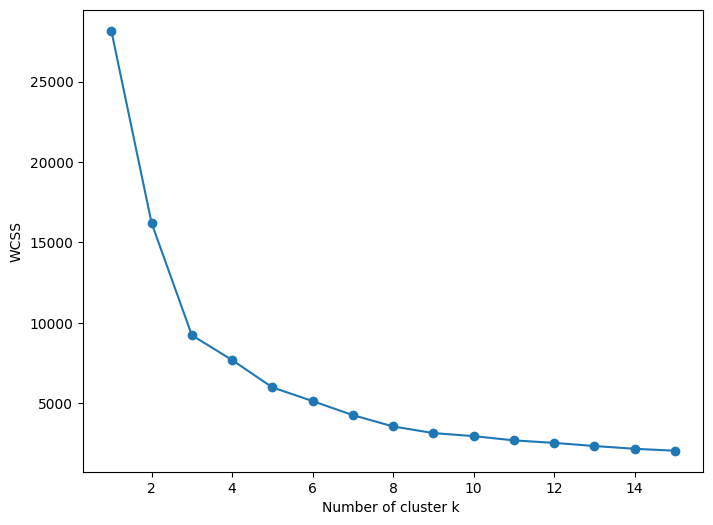

In [121]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data=scaler.fit_transform(segmentation_data)
print(scaled_data[:5])
from sklearn.cluster import KMeans
wcss=[]
for k in range(1,16):
  kmeans=KMeans(n_clusters=k, random_state=42)
  kmeans.fit(scaled_data)
  wcss.append(kmeans.inertia_)
  plt.figure(figsize=(8,6))
plt.plot(range(1,16),wcss,marker='o')
plt.xlabel("Number of cluster k ")
plt.ylabel("WCSS")
plt.show()

In [122]:
kmeans=KMeans(n_clusters=3, random_state=42)
clusters=kmeans.fit_predict(scaled_data)

In [123]:
segmentation_data
segmentation_data['Cluster']= clusters
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster
0,2,53.85,108.15,0.676963,1
1,2,70.70,151.65,0.796013,1
2,8,99.65,820.50,0.805827,1
3,28,104.80,3046.05,0.563031,1
4,49,103.70,5036.30,0.517474,2
...,...,...,...,...,...
7038,72,21.15,1419.40,0.003587,0
7039,24,84.80,1990.50,0.082095,0
7040,72,103.20,7362.90,0.049001,2
7041,11,29.60,346.45,0.302367,0


In [124]:
cluster_summary=segmentation_data.groupby('Cluster').mean()

In [125]:
cluster_summary
cluster_names={
0:'Budget Loyal Customers',
1:'High Risk New Customers',
2:'Loyal Premium CUstomers'
}

In [126]:
segmentation_data['Cluster Segment']=segmentation_data['Cluster'].map(cluster_names)
segmentation_data

,Tenure Months,Monthly Charges,Total Charges,Churn Probability,Cluster,Cluster Segment
0,2,53.85,108.15,0.676963,1,High Risk New Customers
1,2,70.70,151.65,0.796013,1,High Risk New Customers
2,8,99.65,820.50,0.805827,1,High Risk New Customers
3,28,104.80,3046.05,0.563031,1,High Risk New Customers
4,49,103.70,5036.30,0.517474,2,Loyal Premium CUstomers
...,...,...,...,...,...,...
7038,72,21.15,1419.40,0.003587,0,Budget Loyal Customers
7039,24,84.80,1990.50,0.082095,0,Budget Loyal Customers
7040,72,103.20,7362.90,0.049001,2,Loyal Premium CUstomers
7041,11,29.60,346.45,0.302367,0,Budget Loyal Customers


In [127]:
plt.figure(figsize=(10,8))

<Figure size 1000x800 with 0 Axes>

<Figure size 1000x800 with 0 Axes>

<Axes: xlabel='Monthly Charges', ylabel='Churn Probability'>

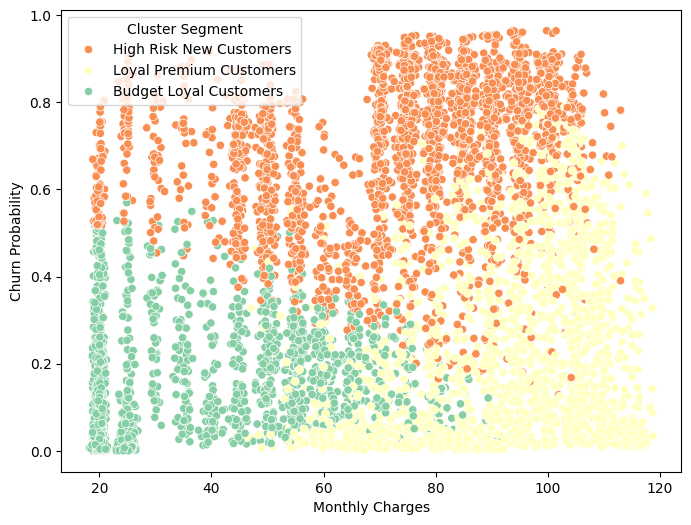

In [128]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Monthly Charges', y='Churn Probability', hue='Cluster Segment', data=segmentation_data, palette='Spectral')

<Axes: xlabel='Tenure Months', ylabel='Churn Probability'>

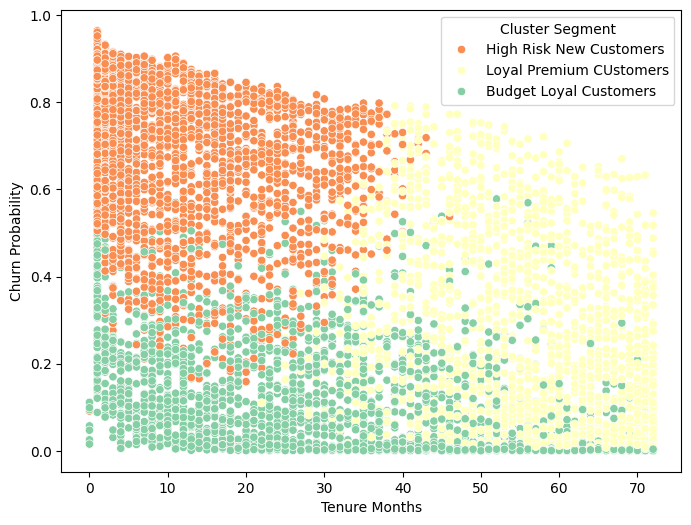

In [129]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Tenure Months', y='Churn Probability', hue='Cluster Segment', data=segmentation_data, palette='Spectral')

<Axes: xlabel='Total Charges', ylabel='Churn Probability'>

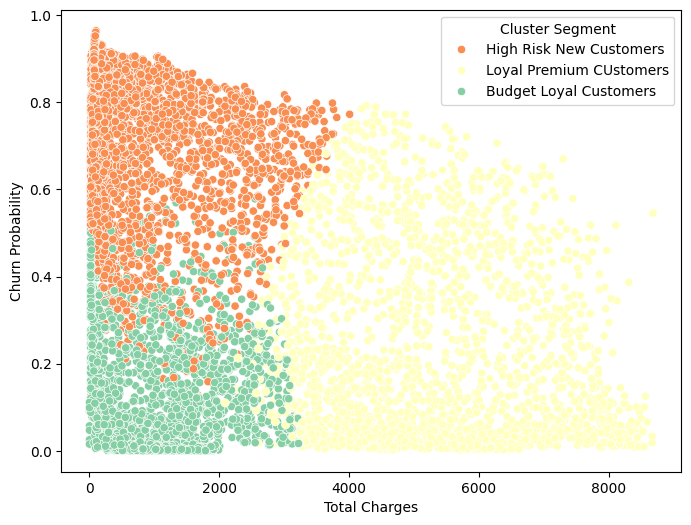

In [130]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Total Charges', y='Churn Probability', hue='Cluster Segment', data=segmentation_data, palette='Spectral')

## Conclusion

- Customers with shorter tenure are more likely to churn.  
- Month-to-month contracts show the highest churn rate.  
- Tenure and Monthly Charges are among the most important features for churn prediction.  
- Random Forest model performed well in predicting customer churn.  